## 0. Preparation

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../../')
from utilities import DF_standardize_date, assign_season

In [3]:
Crick_all = pd.read_csv('../../../dataset/all_with_subtype.csv')
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
new_columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d','seq_a', 'seq_b', 'seq_c', 'seq_d', 
               'serumPassCat', 'virusPassCat', 'serumName', 'virusName', 'label']
dataframe = Crick_all.groupby(group_columns).agg({'seq_id_a': 'first', 'seq_id_b': 'first', 'seq_id_c': 'first', 'seq_id_d': 'first',
                                                  'seq_type_a': 'first', 'seq_type_b': 'first', 'seq_type_c': 'first', 'seq_type_d': 'first',
                                                  'serumName': 'first', 'virusName': 'first', 'serumType': 'first','label': 'mean'}).reset_index()
Crick_all_final = dataframe[new_columns]

Crick_H1N1 = pd.read_excel('../../../data/raw/data4model(Crick-H1N1).xlsx')
Crick_H3N2 = pd.read_excel('../../../data/raw/data4model(Crick-H3N2).xlsx')
Crick_IslID = pd.concat([Crick_H1N1, Crick_H3N2])[['virusName', 'virusIslID']].drop_duplicates(subset=['virusName']).reset_index(drop=True)
Crick_all_final = Crick_all.merge(right=Crick_IslID,how='left', left_on='virusName', right_on='virusName')

H1N1_Meta = pd.read_csv('../../../data/processed/Meta/H1N1/Meta_combined.csv', index_col=False, low_memory=False)
H3N2_Meta = pd.read_csv('../../../data/processed/Meta/H3N2/Meta_combined.csv', index_col=False, low_memory=False)
Crick_Meta = pd.concat([H1N1_Meta, H3N2_Meta], axis=0)

In [25]:
Crick_IslID = pd.concat([Crick_H1N1, Crick_H3N2])[['virusName', 'virusIslID']].drop_duplicates(subset=['virusName']).reset_index(drop=True)
Crick_all_final = Crick_all.merge(right=Crick_IslID,how='left', left_on='virusName', right_on='virusName')

## 1. Subtype distribution

In [27]:
Crick_train, Crick_test = train_test_split(Crick_all_final, test_size=0.1, random_state=42)
Crick_train, Crick_valid = train_test_split(Crick_train, test_size=1/9, random_state=42)

In [28]:
print(Crick_all['serumType'].value_counts())
print(Crick_train['serumType'].value_counts())
print(Crick_valid['serumType'].value_counts())
print(Crick_test['serumType'].value_counts())

serumType
H1N1    55441
H3N2    47801
Name: count, dtype: int64
serumType
H1N1    44445
H3N2    38147
Name: count, dtype: int64
serumType
H1N1    5495
H3N2    4830
Name: count, dtype: int64
serumType
H1N1    5501
H3N2    4824
Name: count, dtype: int64


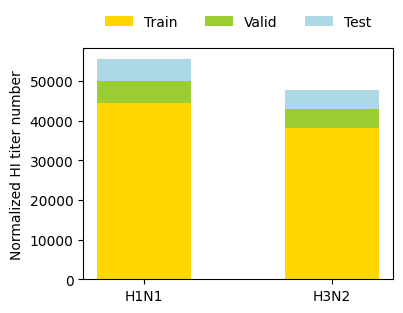

In [21]:
# 数据
categories = ['H1N1', 'H3N2']
values = [55441, 47801]

train_values = [44445, 38147]
valid_values = [5495, 4830]
test_values = [5501, 4824]

# 创建柱状图
fig, ax = plt.subplots(figsize=(4,3))

# 设置柱状图的位置
index = np.arange(len(categories))
bar_width = 0.5  # 增大柱子宽度以减小间隔

# 绘制堆叠柱状图
train_bars = ax.bar(index, train_values, bar_width, label='Train', color='gold')
valid_bars = ax.bar(index, valid_values, bar_width, bottom=train_values, label='Valid', color='yellowgreen')
test_bars = ax.bar(index, test_values, bar_width, bottom=[i+j for i, j in zip(train_values, valid_values)], label='Test', color='lightblue')

# 添加标题和标签
ax.set_ylabel('Normalized HI titer number')
ax.set_xticks(index)
ax.set_xticklabels(categories)

# 添加图例，设置为三列
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, frameon=False)

plt.show()

## 2. Seasonal distribution

In [4]:
Crick_Date = Crick_Meta[['Isolate_Id', 'Collection_Date']]
Date_dict = {key: value for key, value in zip(Crick_Date['Isolate_Id'], Crick_Date['Collection_Date'])}
Crick_all_final['Collection_Date'] = Crick_all_final['virusIslID'].map(Date_dict)

In [5]:
Crick_all_final['Collection_Date'] = pd.to_datetime(Crick_all_final['Collection_Date'], format='%Y-%m-%d', errors='coerce')
try:
    Crick_all_final['Collection_Date'] = Crick_all_final['Collection_Date'].dt.strftime('%Y-%m-%d')
except:
    date = Crick_all_final['Collection_Date'].dt.strftime('%Y-%m')
    date.replace(day=1)
    Crick_all_final['Collection_Date'] = date

In [206]:
seasons = Crick_all_final['Collection_Date'].dropna().apply(assign_season)

In [210]:
value_counts = seasons.value_counts()
Seasons = value_counts.index.get_level_values(0).tolist()
count_list = value_counts.values.tolist()

In [1]:
df = pd.DataFrame({'Seasons': Seasons, 'count': count_list}).sort_values(by='Seasons')
df =df.iloc[:-1,:]
# 设置柱状图的大小
fig, ax = plt.subplots(figsize=(8, 3))

# 绘制柱状图
ax.bar(df['Seasons'], df['count'], color='skyblue')

# 添加标题和标签
ax.set_ylabel('Count', fontsize=12)

# 设置 x 轴标签的旋转角度，以便更好地显示
plt.xticks(rotation=45)

# 显示图表
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.show()

NameError: name 'pd' is not defined

## 3. Location distribution

In [6]:
H1N1_location = H1N1_Meta[['Isolate_Id', 'Location']]
H3N2_location = H3N2_Meta[['Isolate_Id', 'Location']]
Crick_location = pd.concat([H1N1_location, H3N2_location])
location_dict = {key: value for key, value in zip(Crick_location['Isolate_Id'], Crick_location['Location'])}

Crick_IslID = pd.concat([Crick_H1N1, Crick_H3N2])[['virusName', 'virusIslID']].drop_duplicates(subset=['virusName']).reset_index(drop=True)
Crick_all_final = Crick_all.merge(right=Crick_IslID,how='left', left_on='virusName', right_on='virusName')

Crick_all_final['Location'] = Crick_all_final['virusIslID'].map(location_dict)

In [32]:
# pd.Series(Crick_all_final['Location'].unique()).to_csv('./test.csv')
Location_df = pd.read_csv('./test.csv', index_col=False)
map_location_dict = {key: value for key, value in zip(Location_df['key'],Location_df['location'])}
Crick_all_final[['longitude', 'latitude']] = Crick_all_final['Location'].map(map_location_dict).str.split(',', expand=True)

In [ ]:
import pandas as pd

value_counts = Crick_all_final[['longitude', 'latitude']].value_counts()
longitude_list = value_counts.index.get_level_values(0).tolist()
latitude_list = value_counts.index.get_level_values(1).tolist()
count_list = value_counts.values.tolist()
data = {
    'latitude': latitude_list,
    'longitude': longitude_list,
    'weight': count_list
}
df = pd.DataFrame(data)

In [147]:
import folium
from folium.plugins import HeatMap

# 创建地图
map_center = [0, 20]  # 美国的中心点
m = folium.Map(location=map_center, zoom_start=2)

# 准备热图数据
heat_data = [[row['latitude'], row['longitude'], row['weight']] for index, row in df.iterrows()]

# 添加热图
HeatMap(heat_data, radius=14).add_to(m)
m

## 4. Performance

In [8]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from utilities import load_embedding, print_exams
import torch
import torch.nn.functional as F

In [9]:
class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask


In [7]:
H1N1_Meta = pd.read_csv('../../../data/processed/Meta/H1N1/Meta_combined.csv', index_col=False, low_memory=False)
H3N2_Meta = pd.read_csv('../../../data/processed/Meta/H3N2/Meta_combined.csv', index_col=False, low_memory=False)
Crick_Meta = pd.concat([H1N1_Meta, H3N2_Meta], axis=0).drop_duplicates(subset=['Isolate_Id'])

In [10]:
Crick_all = pd.read_csv('../../../dataset/all_with_ID.csv')
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
new_columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d','seq_a', 'seq_b', 'seq_c', 'seq_d', 
               'serumPassCat', 'virusPassCat', 'serumName', 'virusName', 'virus_ISL_ID', 'label']
dataframe = Crick_all.groupby(group_columns).agg({'seq_id_a': 'first', 'seq_id_b': 'first', 'seq_id_c': 'first', 'seq_id_d': 'first',
                                                  'seq_type_a': 'first', 'seq_type_b': 'first', 'seq_type_c': 'first', 'seq_type_d': 'first',
                                                  'serumName': 'first', 'virusName': 'first', 'virus_ISL_ID': 'first','label': 'mean'}).reset_index()
Crick_all_final = dataframe[new_columns]

extra_info = Crick_Meta[['Isolate_Id', 'Subtype', 'Location', 'Collection_Date']]
Crick_all_final = Crick_all_final.merge(right=extra_info, how='left', left_on='virus_ISL_ID', right_on='Isolate_Id')

train_data, test_data = train_test_split(Crick_all_final, test_size=0.1, random_state=42)
train_data, valid_data = train_test_split(train_data, test_size=1/9, random_state=42)

test_dataset = fluProfiler_Dataset(test_data)
test_dataloader = DataLoader(test_dataset, batch_size=200, shuffle=False)

In [11]:
Crick_all_final['season'] = Crick_all_final['Collection_Date'].apply(assign_season)

In [12]:
import sys
sys.path.append('../../')
from model_001 import LucaQuadruple_final_dropout, fluProfiler_Config
from tqdm import tqdm
import os
import torch
import pandas as pd
import numpy as np
from utilities import load_embedding
from torch.utils.data import Dataset, DataLoader
import pickle
from utilities import print_exams

In [13]:
device = torch.device('cuda:1')
model = torch.load('/data/chenyihao/fluProfiler_source/model/model_001.pth', weights_only=False, map_location=device)

In [14]:
import os
from tqdm import tqdm

embedding_df = test_data
# load embedding
sequence_names = pd.concat([embedding_df['seq_id_a'],embedding_df['seq_id_b'],
                            embedding_df['seq_id_c'],embedding_df['seq_id_d']]).unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
IDs, embeddings = load_embedding("/data/chenyihao/embedding", files=sequence_names)
# embeddings = [emb.to(device) for emb in embeddings]
emb_dict = dict(zip(IDs, embeddings))

Loading tensor:   0%|          | 0/6419 [00:00<?, ?file/s]

Loading tensor: 100%|██████████| 6419/6419 [08:11<00:00, 13.06file/s]


In [16]:
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in test_dataloader:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                     matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                     matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                     labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

print_exams(reference_ls, prediction_ls)

KeyboardInterrupt: 

In [ ]:
test_data['prediction'] = prediction_ls

In [97]:
test_data.to_csv('./mytestddd.csv', index=False)

In [150]:
country = []
for row in Crick_all_final['Location'].str.split('/'):
    if len(row) < 2:
        print(row)
        country.append('Unknown')
    else:
        country.append(row[1].replace(' ',''))

['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']


In [154]:
country = []
for row in Crick_all_final['Location'].str.split('/'):
    if len(row) < 2:
        print(row)
        country.append('Unknown')
    else:
        country.append(row[1].replace(' ',''))
data_add_country = Crick_all_final.copy()
data_add_country['Country'] = country

country = []
for row in test_data['Location'].str.split('/'):
    if len(row) < 2:
        print(row)
        country.append('Unknown')
    else:
        country.append(row[1].replace(' ',''))
test_data_add_country = test_data.copy()
test_data_add_country['Country'] = country

['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']
['North America']


In [157]:
Count = data_add_country['Country'].value_counts()
test_Count = test_data_add_country['Country'].value_counts()

In [23]:
from sklearn.metrics import mean_absolute_error

In [209]:
MAE = []
for loc in test_Count.index[test_Count > 40]:
    data = test_data_add_country[test_data_add_country['Country'] == loc]
    MAE.append(mean_absolute_error(data['label'], data['prediction']))

In [210]:
df = pd.DataFrame({'count': Count[test_Count[test_Count > 40].index], 'MAE': MAE})

In [169]:
df.to_csv('dfdsfsf.csv')

In [200]:
# 安装一次即可
# pip install pandas plotly pycountry

import pandas as pd
import plotly.express as px
import pycountry

data = {key: value for key, value in zip(df.index, df['MAE'])}

# 2) 把字典变成 DataFrame
df = pd.DataFrame(list(data.items()), columns=['Country_raw', 'count'])

# 3) 把国家名转换成 ISO-3 代码（plotly 默认用 ISO-3）
def country_to_iso3(name):
    # 手工修正几个 plotly 不认的非标准名称
    mapping = {
        'Korea,Republicof':'KOR',
        'RussianFederation':'RUS',
        'Iran,IslamicRepublicof':'IRN',
        'Moldova,Republicof':'MDA',
        'Macedonia,theformerYugoslavRepublicof':'MKD',
        'UnitedStates':'USA',
        'UnitedKingdom':'GBR',
        'CzechRepublic':'CZE',
        'PalestinianTerritory':'PSE',
        'HongKong(SAR)':'HKG',
        'Unknown':None  # 去掉 Unknown
    }
    if name in mapping:
        return mapping[name]
    try:
        return pycountry.countries.lookup(name).alpha_3
    except LookupError:
        return None

df['iso_alpha'] = df['Country_raw'].apply(country_to_iso3)
df = df.dropna(subset=['iso_alpha'])

# 4) 画图
fig = px.choropleth(
    df,
    locations='iso_alpha',
    color='count',
    hover_name='Country_raw',
    color_continuous_scale='Reds',
    title='Country heatmap by count'
)
fig.update_layout(geo=dict(showframe=False, projection_type='natural earth'))
fig.show()

In [191]:
test_H1N1 = test_data_add_country[test_data_add_country['Subtype'] == 'A / H1N1']
test_H3N2 = test_data_add_country[test_data_add_country['Subtype'] == 'A / H3N2']

In [190]:
test_H1N1['label']

Series([], Name: label, dtype: float64)

In [192]:
print_exams(test_H1N1['label'], test_H1N1['prediction'])
print_exams(test_H3N2['label'], test_H3N2['prediction'])

MAE:  0.5691747293715702
MSE:  0.5304368285975984
pearson correlation:  PearsonRResult(statistic=0.9122041077944625, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.813028908425797, pvalue=0.0)
R2_score:  0.7998474610336619
MAE:  0.601610349718211
MSE:  0.622809914533203
pearson correlation:  PearsonRResult(statistic=0.8973730866519715, pvalue=0.0)
spearman correlation:  SignificanceResult(statistic=0.896264215455023, pvalue=0.0)
R2_score:  0.7544609776557741


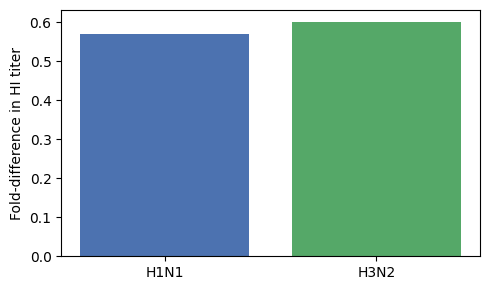

In [196]:
import matplotlib.pyplot as plt

y = [0.5691747293715702, 0.601610349718211]
labels = ['H1N1', 'H3N2']

plt.figure(figsize=(5,3))
plt.bar(labels, y, color=['#4c72b0','#55a868'])
plt.ylabel('Fold-difference in HI titer')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn

In [19]:
dddd['season'] = dddd['Collection_Date'].apply(assign_season)

In [24]:
MAE = []
for S in dddd['season'].unique():
    data = dddd[dddd['season'] == S]
    MAE.append(mean_absolute_error(data['label'],data['prediction']))

In [17]:
dddd = pd.read_csv('./mytestddd.csv', index_col=False)

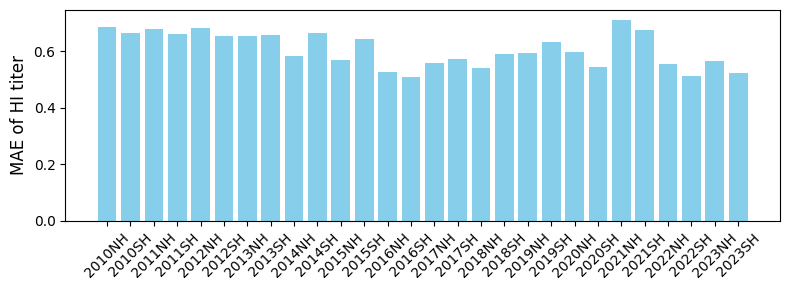

In [26]:
df = pd.DataFrame({'Seasons': dddd['season'].unique(), 'count': MAE}).sort_values(by='Seasons')
df = df.iloc[8:-1,:]

# 设置柱状图的大小
fig, ax = plt.subplots(figsize=(8, 3))

# 绘制柱状图
ax.bar(df['Seasons'], df['count'], color='skyblue')

# 添加标题和标签
ax.set_ylabel('MAE of HI titer', fontsize=12)

# 设置 x 轴标签的旋转角度，以便更好地显示
plt.xticks(rotation=45)

# 显示图表
plt.tight_layout()  # 自动调整子图参数，使之填充整个图像区域
plt.show()